In [27]:
import sys 
sys.path.insert(0, '../')

import numpy as np
import matplotlib.pyplot as plt

In [44]:
from src.utils import load_signals_and_arousals, downsample_signal
from src.dsp import apply_continuous_filters
from src.config import PreprocessConfig
cfg = PreprocessConfig()
channels = list(cfg.eeg_indices.values())

example_patient_path = "../data/raw/tr03-0005"
signals, _, sleep_stages = load_signals_and_arousals(example_patient_path, channels, include_sleep_stages=True)

signals = downsample_signal(signals, downsample_factor=2)
sleep_stages = {key : values[::2] for key, values in sleep_stages.items()}
signals = apply_continuous_filters(signals, cfg)

..\data\raw\tr03-0005\tr03-0005.mat ..\data\raw\tr03-0005\tr03-0005-arousal.mat


In [45]:
def find_stable_blocks(stage_mask: np.ndarray, min_len_samp: int) -> list:
    """
    Finds contiguous blocks of 1s in a boolean array that are >= min_len_samp.
    Returns a list of (onset_index, offset_index) tuples.
    """
    # Pad with 0s to easily detect edges if the mask starts or ends with 1
    edges = np.diff(np.concatenate(([0], stage_mask, [0])))
    
    # 1 indicates a transition from 0 to 1 (onset)
    # -1 indicates a transition from 1 to 0 (offset)
    onsets = np.where(edges == 1)[0]
    offsets = np.where(edges == -1)[0]
    
    valid_blocks = []
    for on, off in zip(onsets, offsets):
        if (off - on) >= min_len_samp:
            valid_blocks.append((on, off))
            
    return valid_blocks

In [46]:
blocks = find_stable_blocks(sleep_stages['wake'], min_len_samp=100*30)
blocks

[(np.int64(36000), np.int64(60000)),
 (np.int64(66000), np.int64(69000)),
 (np.int64(84000), np.int64(87000)),
 (np.int64(108000), np.int64(114000)),
 (np.int64(117000), np.int64(123000)),
 (np.int64(126000), np.int64(141000)),
 (np.int64(144000), np.int64(165000)),
 (np.int64(414000), np.int64(420000)),
 (np.int64(492000), np.int64(495000)),
 (np.int64(681000), np.int64(687000)),
 (np.int64(816000), np.int64(819000)),
 (np.int64(831000), np.int64(834000)),
 (np.int64(1020000), np.int64(1029000)),
 (np.int64(1269000), np.int64(1281000)),
 (np.int64(1284000), np.int64(1287000)),
 (np.int64(1407000), np.int64(1410000)),
 (np.int64(1542000), np.int64(1578000)),
 (np.int64(1584000), np.int64(1587000)),
 (np.int64(1596000), np.int64(1608000)),
 (np.int64(1611000), np.int64(1635000)),
 (np.int64(1638000), np.int64(1644000)),
 (np.int64(1647000), np.int64(1677000)),
 (np.int64(1680000), np.int64(2178000)),
 (np.int64(2184000), np.int64(2196000)),
 (np.int64(2199000), np.int64(2235000)),
 (np.

In [47]:
STAGE_TO_INT = {
    'wake': 0,
    'nonrem1': 1,
    'nonrem2': 2,
    'nonrem3': 3,
    'rem': 4
}

def extract_sleep_stage_windows(
    sleep_stages: dict, 
    full_spectral_timeline: np.ndarray, 
    fs: int, 
    hop_length: int,
    win_sec: int = 30
) -> tuple[np.ndarray, np.ndarray]:
    """
    Extracts matching STFT features from stable sleep stages.
    Returns:
        spectral_features: np.ndarray of shape (n_windows, time_steps, features)
        labels: np.ndarray of shape (n_windows, n_classes) as one-hot vectors
    """
    # 30 seconds converted to raw samples
    win_samp = win_sec * fs
    
    # Standard 30s epochs do not overlap, so step equals the window size
    step_samp = win_samp 
    
    all_features = []
    all_labels = []
    
    for stage_name, mask in sleep_stages.items():
        # Ignore undefined or unmapped stages
        if stage_name == 'undefined' or stage_name not in STAGE_TO_INT:
            continue
            
        stage_idx = STAGE_TO_INT[stage_name]
        
        # 1. Get contiguous blocks for this stage
        blocks = find_stable_blocks(mask, win_samp)
        
        # 2. Extract consecutive 30-second windows
        for on, off in blocks:
            for start_idx in range(on, off - win_samp + 1, step_samp):
                end_idx = start_idx + win_samp
                
                # Convert raw sample indices to STFT step indices
                start_step_idx = start_idx // hop_length
                end_step_idx = end_idx // hop_length
                
                # Slice STFT Features
                spec_win = full_spectral_timeline[start_step_idx:end_step_idx, :]
                
                all_features.append(spec_win)
                all_labels.append(stage_idx)
                
    # 3. Stack everything into flat numpy arrays
    spectral_features = np.array(all_features)
    labels_int = np.array(all_labels)
    
    # 4. One-hot encode the labels using an identity matrix trick
    num_classes = len(STAGE_TO_INT)
    labels_onehot = np.eye(num_classes)[labels_int]
    
    return spectral_features, labels_onehot

In [60]:
from src.dsp import compute_full_recording_bandpower

full_spectral_timeline = compute_full_recording_bandpower(signals, fs=100, n_fft=200, hop_length=25)
spectral_windows, labels = extract_sleep_stage_windows(sleep_stages, full_spectral_timeline, fs=100, hop_length=25)

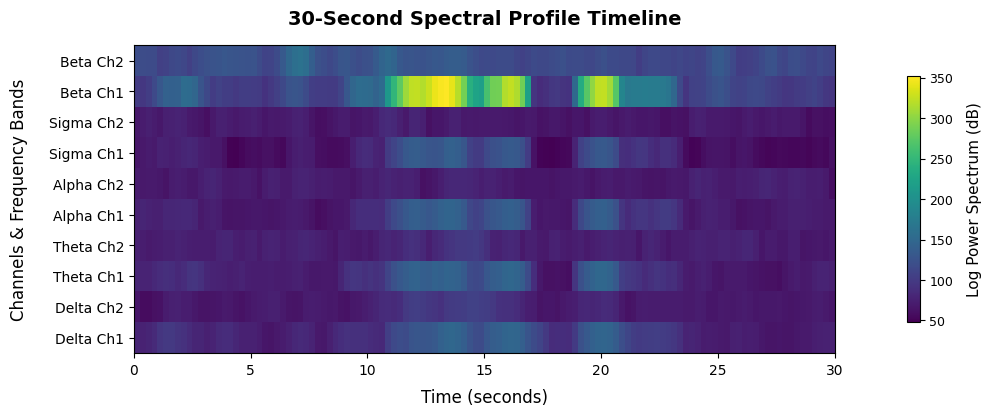

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# 1. CRITICAL FIX: Transpose the array!
# This converts shape from (120, 10) to (10, 120), placing Time on the X-axis.
plot_data = spectral_windows[0].T 

# Define the exact layout of your 10 features
feature_labels = [
    'Delta Ch1', 'Delta Ch2',
    'Theta Ch1', 'Theta Ch2',
    'Alpha Ch1', 'Alpha Ch2',
    'Sigma Ch1', 'Sigma Ch2',
    'Beta Ch1',  'Beta Ch2'
]
band_names = ['Delta', 'Theta', 'Alpha', 'Sigma', 'Beta']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] 

# Initialize Plot
fig, ax = plt.subplots(figsize=(14, 4), dpi=100)

# Plot the matrix
im = ax.imshow(
    plot_data, 
    aspect='auto', 
    cmap='viridis', 
    origin='lower', 
    extent=[0, 30, -0.5, 9.5] # X goes 0 to 30s, Y fits our 10 rows
)

# Refine Axes and Labels
ax.set_title("30-Second Spectral Profile Timeline", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Time (seconds)", fontsize=12, labelpad=8)
ax.set_ylabel("Channels & Frequency Bands", fontsize=12, labelpad=15)

# Set ticks exactly in the middle of each channel row
ax.set_yticks(range(10))
ax.set_yticklabels(feature_labels, fontsize=10)
ax.set_xticks(np.arange(0, 31, 5)) 

# Add Colorbar
cbar = fig.colorbar(im, ax=ax, pad=0.08, shrink=0.8)
cbar.set_label("Log Power Spectrum (dB)", fontsize=11, labelpad=10)
cbar.ax.tick_params(labelsize=9)

# 2. CRITICAL FIX: Adjusted bracket coordinates
# Make room on the left side of the figure for the brackets
plt.subplots_adjust(left=0.25)

plt.show()

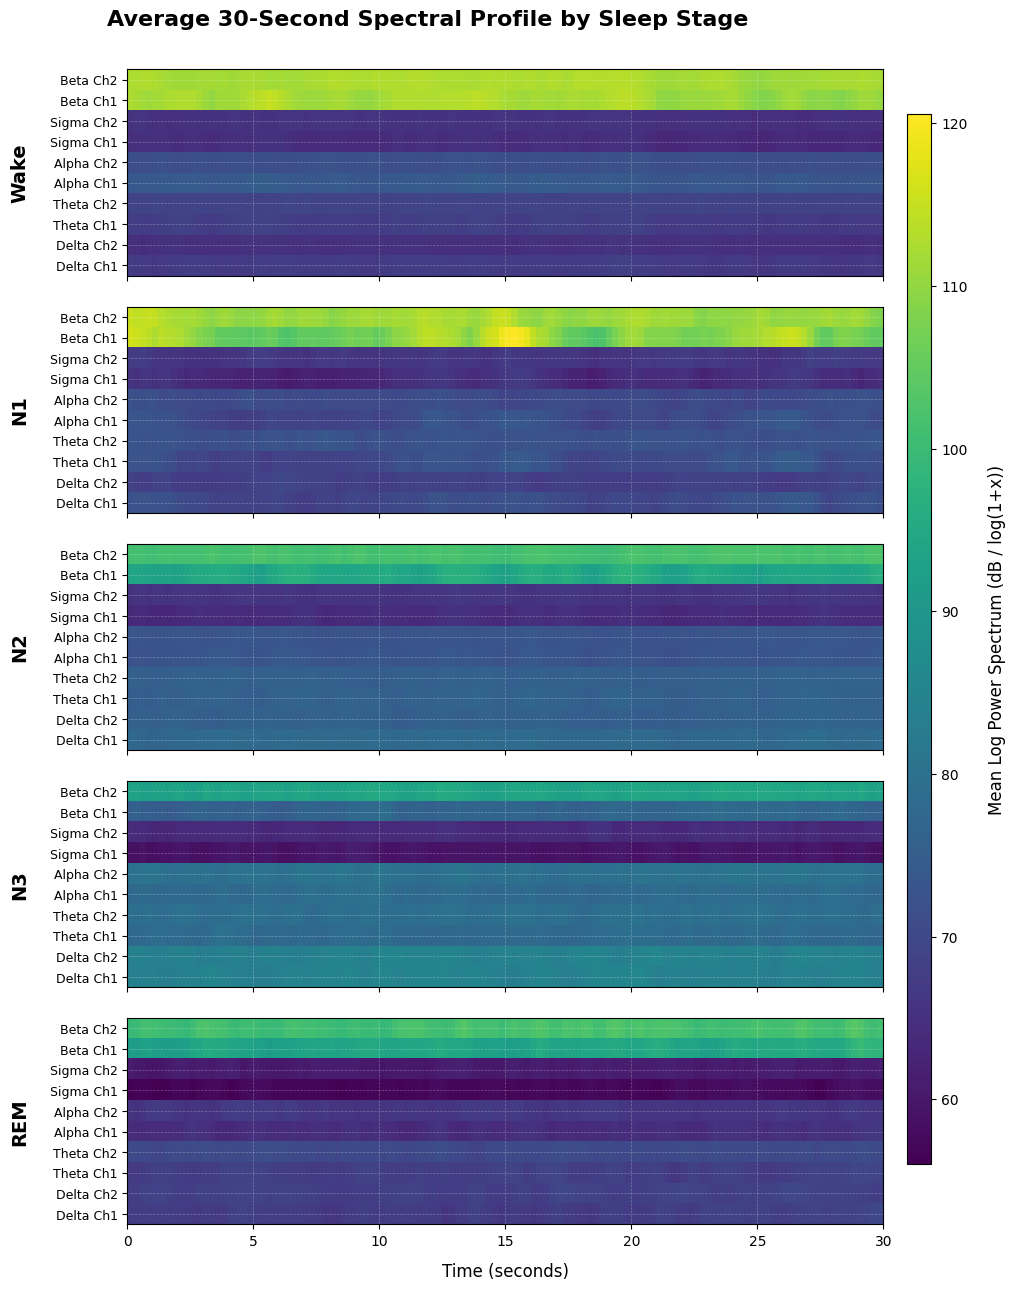

In [62]:
class_indices = np.argmax(labels, axis=1)

stage_means = {}
global_min, global_max = float('inf'), float('-inf')

for i in range(5):
    # Extract all windows for class i
    stage_data = spectral_windows[class_indices == i]
    
    if len(stage_data) > 0:
        # Mean across the window axis (axis=0) and Transpose to (10, 120)
        mean_window = np.mean(stage_data, axis=0).T
        stage_means[i] = mean_window
        
        # Track global min/max for the shared colorbar
        global_min = min(global_min, mean_window.min())
        global_max = max(global_max, mean_window.max())

# 2. Setup a 5x1 grid of subplots sharing the X-axis
fig, axes = plt.subplots(len(stage_means), 1, figsize=(12, 3 * len(stage_means)), sharex=True, dpi=100)

INT_TO_STAGE = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}

# Make room on the left for brackets, and on the right for the shared colorbar
plt.subplots_adjust(left=0.25, right=0.88, hspace=0.15)

for idx, (stage_int, ax) in enumerate(zip(stage_means.keys(), axes)):
    mean_data = stage_means[stage_int]
    stage_name = INT_TO_STAGE[stage_int]
    
    # Plot using shared vmin and vmax
    im = ax.imshow(
        mean_data, 
        aspect='auto', 
        cmap='viridis', 
        origin='lower', 
        extent=[0, 30, -0.5, 9.5],
        vmin=global_min,
        vmax=global_max
    )
    
    # Text and Labels
    ax.set_ylabel(f"{stage_name}", fontsize=14, fontweight='bold', labelpad=15)
    ax.set_yticks(range(10))
    ax.set_yticklabels(feature_labels, fontsize=9)
    ax.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.3)

# X-axis formatting only on the bottom-most plot
axes[-1].set_xlabel("Time (seconds)", fontsize=12, labelpad=10)
axes[-1].set_xticks(np.arange(0, 31, 5))

# 3. Add a single shared colorbar on the right side
# [left, bottom, width, height] as fractions of figure
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Mean Log Power Spectrum (dB / log(1+x))", fontsize=12, labelpad=15)

# Overall Title
fig.suptitle("Average 30-Second Spectral Profile by Sleep Stage", fontsize=16, fontweight='bold', y=0.92)

plt.show()

[*] Running PCA projection...
[*] Running t-SNE on 845 samples... This might take a minute.


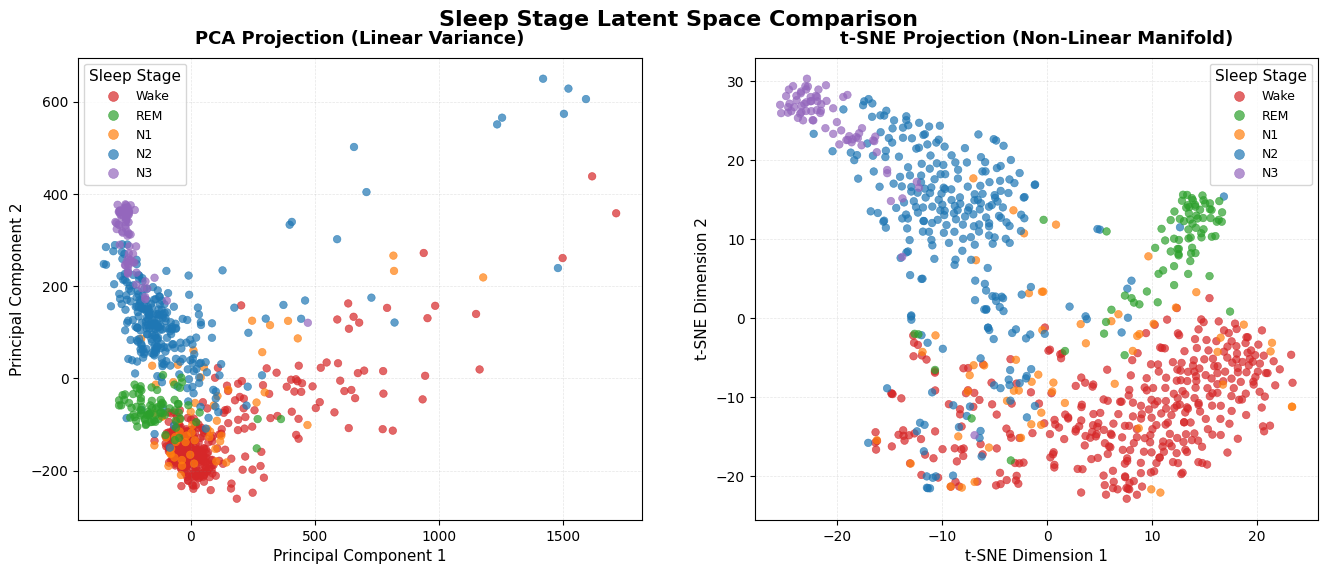

In [63]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_pca_tsne(windows, labels, samples_per_class):
    n_samples = windows.shape[0]
    X_flat = windows.reshape(n_samples, -1)

    # Convert one-hot labels back to 1D class integer arrays
    y_indices = np.argmax(labels, axis=1)

    selected_indices = []

    for i in range(5):
        class_idx = np.where(y_indices == i)[0]
        if len(class_idx) > 0:
            n_choose = min(samples_per_class, len(class_idx))
            chosen = np.random.choice(class_idx, n_choose, replace=False)
            selected_indices.extend(chosen)

    selected_indices = np.array(selected_indices)

    # Extract the sub-sampled datasets
    X_sub = X_flat[selected_indices]
    y_sub = y_indices[selected_indices]

    # 3. Compute Dimensionality Reductions
    print("[*] Running PCA projection...")
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_sub)

    print(f"[*] Running t-SNE on {len(X_sub)} samples... This might take a minute.")
    # Note: Changed 'max_iter' to 'n_iter' to match standard scikit-learn syntax
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    X_tsne = tsne.fit_transform(X_sub)

    # 4. Plotting Setup
    INT_TO_STAGE = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
    y_str = [INT_TO_STAGE[i] for i in y_sub]

    palette = {
        'Wake': '#d62728',  # Red
        'REM': '#2ca02c',   # Green
        'N1': '#ff7f0e',    # Orange
        'N2': '#1f77b4',    # Blue
        'N3': '#9467bd'     # Purple
    }
    hue_order = ['Wake', 'REM', 'N1', 'N2', 'N3']

    # Initialize a 2-row, 1-column figure canvas
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

    # --- SUBPLOT 1: PCA ---
    sns.scatterplot(
        x=X_pca[:, 0], 
        y=X_pca[:, 1],
        hue=y_str,
        palette=palette,
        hue_order=hue_order,
        alpha=0.7,
        s=30,
        edgecolor=None,
        ax=ax1
    )
    ax1.set_title("PCA Projection (Linear Variance)", fontsize=13, fontweight='bold', pad=10)
    ax1.set_xlabel("Principal Component 1", fontsize=11)
    ax1.set_ylabel("Principal Component 2", fontsize=11)
    ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2)
    ax1.legend(title="Sleep Stage", title_fontsize=11, fontsize=9, markerscale=1.3, loc='best')

    # --- SUBPLOT 2: t-SNE ---
    sns.scatterplot(
        x=X_tsne[:, 0], 
        y=X_tsne[:, 1],
        hue=y_str,
        palette=palette,
        hue_order=hue_order,
        alpha=0.7,
        s=30,
        edgecolor=None,
        ax=ax2
    )
    ax2.set_title("t-SNE Projection (Non-Linear Manifold)", fontsize=13, fontweight='bold', pad=10)
    ax2.set_xlabel("t-SNE Dimension 1", fontsize=11)
    ax2.set_ylabel("t-SNE Dimension 2", fontsize=11)
    ax2.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2)
    ax2.legend(title="Sleep Stage", title_fontsize=11, fontsize=9, markerscale=1.3, loc='best')

    # Aesthetics and Export
    plt.suptitle("Sleep Stage Latent Space Comparison", fontsize=16, fontweight='bold', y=0.96)
    plt.subplots_adjust(hspace=0.25) # Give vertical breathing room between the graphs
    # plt.savefig("sleep_stage_dimensionality_comparison.png", bbox_inches='tight')
    plt.show()

plot_pca_tsne(spectral_windows, labels, samples_per_class=500)

# Load full dataset

In [64]:
def load_data(split_name):
    print(f"[*] Loading {split_name} dataset into RAM...")
    # Matches the specific file names specified in your notebook sample
    file_path = f"../data/processed/{split_name}.npz"
    data = np.load(file_path)
    X = data['spectral_band_windows']
    y = data['sleep_stages']
    
    return X, y

all_windows, all_labels = load_data("sleep_stage_train")

[*] Loading sleep_stage_train dataset into RAM...


In [65]:
print(all_windows.shape, all_labels.shape)

(167216, 120, 30) (167216, 5)


[*] Running PCA projection...
[*] Running t-SNE on 500 samples... This might take a minute.


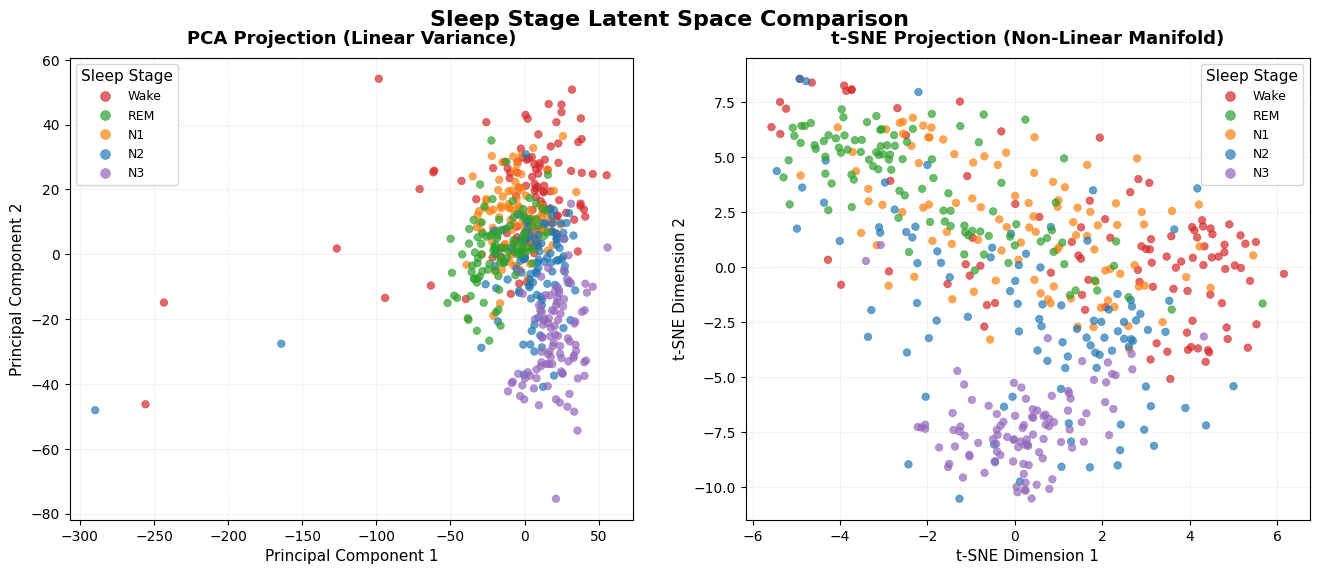

In [68]:
plot_pca_tsne(all_windows, all_labels, samples_per_class=100)